In [1]:
import pandas as pd

In [2]:
df=pd.read_csv(r"C:\Users\VISHAL\Desktop\Raw data\raw_data.csv")


In [3]:
# create tenure categories
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 36, 72],
    labels=['0-12', '13-36', '37+']
)

In [4]:
# count customers
tenure_counts = df['tenure_group'].value_counts()

In [5]:
# import matplotlib
import matplotlib.pyplot as plt

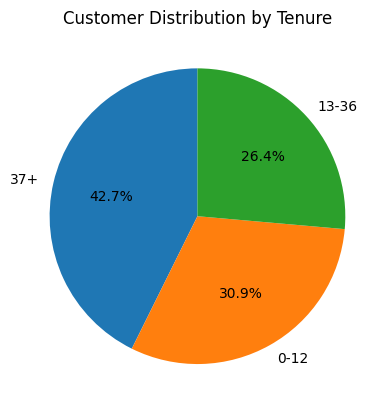

In [6]:
# for pie chart
plt.figure()

tenure_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Customer Distribution by Tenure")
plt.ylabel('')  # remove y label
plt.show()

In [7]:
#Calculate average
avg_charges = df.groupby('tenure_group')['MonthlyCharges'].mean()

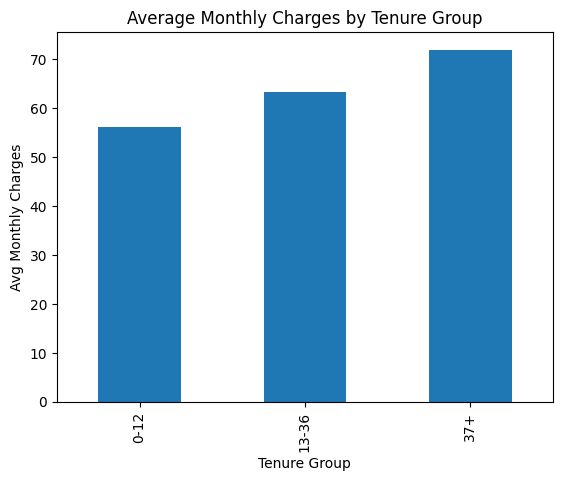

In [8]:
# Bar chart
avg_charges.plot(kind='bar')
plt.title("Average Monthly Charges by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Avg Monthly Charges")
plt.show()

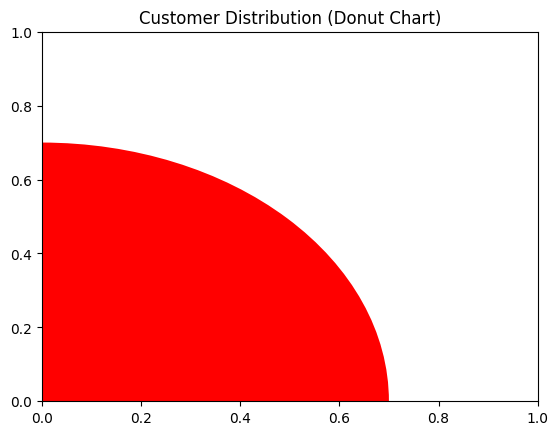

In [11]:
# create donut hole
centre_circle = plt.Circle((0, 0), 0.70, fc='red')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Customer Distribution (Donut Chart)")
plt.show()

In [17]:
# import plotly
import plotly.express as pt

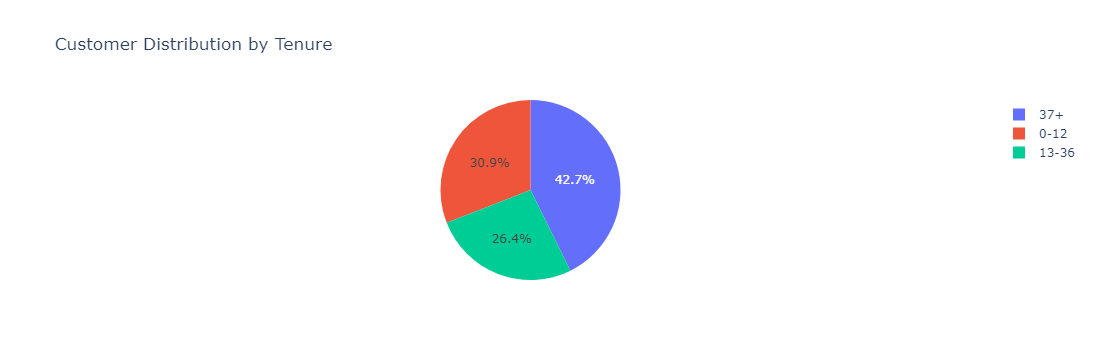

In [18]:
# Pie chart
fig = pt.pie(
    values=tenure_counts.values,
    names=tenure_counts.index,
    title="Customer Distribution by Tenure"
)

fig.show()

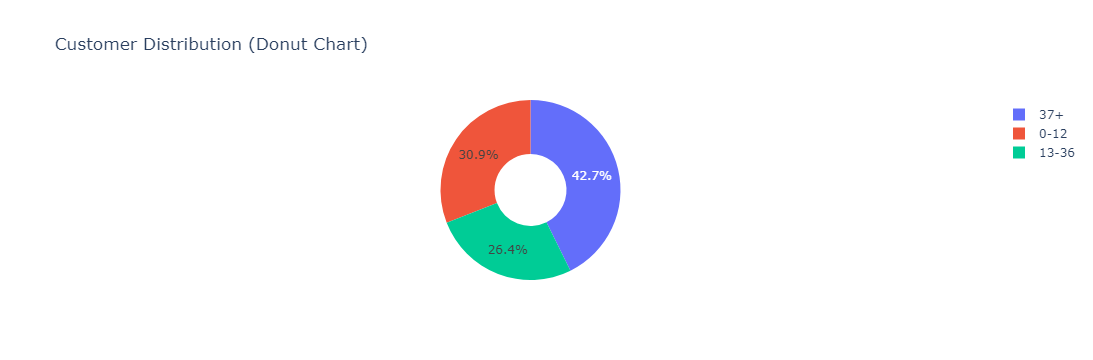

In [19]:
# Donut chart (Plotly)
fig = pt.pie(
    values=tenure_counts.values,
    names=tenure_counts.index,
    hole=0.4, 
    # creates donut
    title="Customer Distribution (Donut Chart)"
)

fig.show()

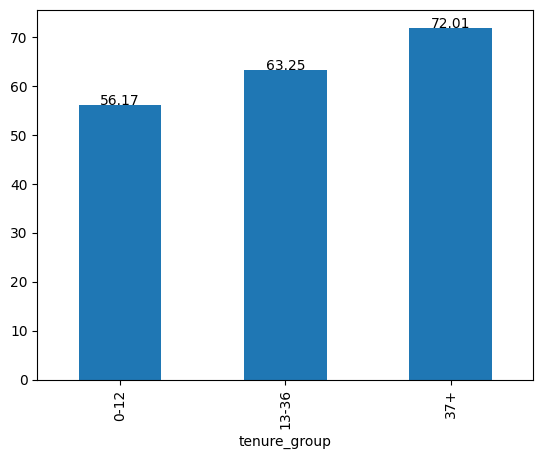

In [20]:
# adding annotations to highlight significant trends
ax = avg_charges.plot(kind='bar')

for i, v in enumerate(avg_charges):
    ax.text(i, v, round(v,2), ha='center')

plt.show()